0) Imports

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mplsoccer import Pitch, VerticalPitch


1) Carga de datos

In [2]:
DATA_PATH = "../data/processed/events.parquet"  # ajusta
events = pd.read_parquet(DATA_PATH) if DATA_PATH.endswith(".parquet") else pd.read_csv(DATA_PATH)
events.head()


,match_id,event_id,index,period,timestamp,minute,second,type,possession,possession_team,...,carry_end_location,shot_outcome,shot_statsbomb_xg,shot_body_part,shot_type,shot_technique,shot_first_time,shot_one_on_one,shot_open_goal,shot_aerial_won
0,3930158,f2207d37-beed-4073-84a5-f9d696e2afdd,1,1,00:00:00.000,0,0,Starting XI,1,Germany,...,None,NaN,NaN,NaN,NaN,NaN,None,None,None,None
1,3930158,43e494fe-4871-4b2a-a509-a325c17a5e3f,2,1,00:00:00.000,0,0,Starting XI,1,Germany,...,None,NaN,NaN,NaN,NaN,NaN,None,None,None,None
2,3930158,d9de8fe7-3122-4067-a1c2-a742c7edb2b8,3,1,00:00:00.000,0,0,Half Start,1,Germany,...,None,NaN,NaN,NaN,NaN,NaN,None,None,None,None
3,3930158,455f819f-3926-4ed4-a0e9-4e9e4d0bf95a,4,1,00:00:00.000,0,0,Half Start,1,Germany,...,None,NaN,NaN,NaN,NaN,NaN,None,None,None,None
4,3930158,df6f6fb7-f0b0-4561-9171-f4172f5e97e7,5,1,00:00:01.191,0,1,Pass,2,Germany,...,None,NaN,NaN,NaN,NaN,NaN,None,None,None,None


2) Normalización mínima (type/team/player + x,y)

In [3]:
def _unpack_xy(series, idx):
    return series.apply(lambda v: v[idx] if isinstance(v, (list, tuple)) and len(v) > idx else np.nan)

# type
if "type" not in events.columns and "type.name" in events.columns:
    events["type"] = events["type.name"]
elif "type.name" in events.columns:
    events["type"] = events["type.name"]

# team / player
if "team" not in events.columns and "team.name" in events.columns:
    events["team"] = events["team.name"]
if "player" not in events.columns and "player.name" in events.columns:
    events["player"] = events["player.name"]

# coords
if "location" in events.columns:
    events["x"] = _unpack_xy(events["location"], 0)
    events["y"] = _unpack_xy(events["location"], 1)
elif not {"x","y"}.issubset(events.columns):
    raise ValueError("No encuentro 'location' ni columnas 'x','y'. Ajusta el mapeo.")

events[["type","team","player","x","y"]].head()


,type,team,player,x,y
0,Starting XI,Germany,NaN,NaN,NaN
1,Starting XI,Scotland,NaN,NaN,NaN
2,Half Start,Germany,NaN,NaN,NaN
3,Half Start,Scotland,NaN,NaN,NaN
4,Pass,Germany,Kai Havertz,61.0,40.1


3) Filtrar Dribbles + outcome (Completed/Incomplete)

In [15]:
dribbles = events[events["type"].eq("Dribble")].copy()

# outcome
out_col = "dribble.outcome.name"
if out_col in dribbles.columns:
    dribbles["outcome"] = dribbles[out_col]
else:
    dribbles["outcome"] = np.nan  # si no existe, asumimos que no tenemos outcome explícito

# StatsBomb a menudo: outcome solo existe si es fallido.
# Por tanto, "completed" = outcome es NaN OR outcome indica completo
dribbles["completed"] = (
    dribbles["outcome"].isna()
    | dribbles["outcome"].isin(["Complete", "Completed", "Successful", "Success"])
)

# (opcional) también puedes crear "failed" explícito
dribbles["failed"] = dribbles["outcome"].isin(["Incomplete", "Incompleted", "Unsuccessful", "Fail", "Failed"])

dribbles[["team","player","x","y","outcome","completed","failed"]].head()


,team,player,x,y,outcome,completed,failed
72,Germany,Jamal Musiala,106.6,23.3,NaN,True,False
462,Scotland,Ryan Christie,91.9,3.4,NaN,True,False
484,Germany,Jamal Musiala,49.5,77.0,NaN,True,False
524,Germany,Jamal Musiala,56.8,16.8,NaN,True,False
564,Scotland,Scott McTominay,40.4,24.8,NaN,True,False


4) Helpers de plotting

In [16]:
def draw_pitch(title=None, vertical=False):
    pitch = VerticalPitch(pitch_type="statsbomb", line_zorder=2) if vertical else Pitch(pitch_type="statsbomb", line_zorder=2)
    fig, ax = pitch.draw(figsize=(10, 7))
    if title:
        fig.suptitle(title, fontsize=14)
    return pitch, fig, ax

def plot_dribbles(df, title, vertical=False, s=55, alpha=0.7):
    pitch, fig, ax = draw_pitch(title=title, vertical=vertical)
    pitch.scatter(df["x"], df["y"], ax=ax, s=s, alpha=alpha)
    return fig, ax


5) Dribble map por equipo (todos)

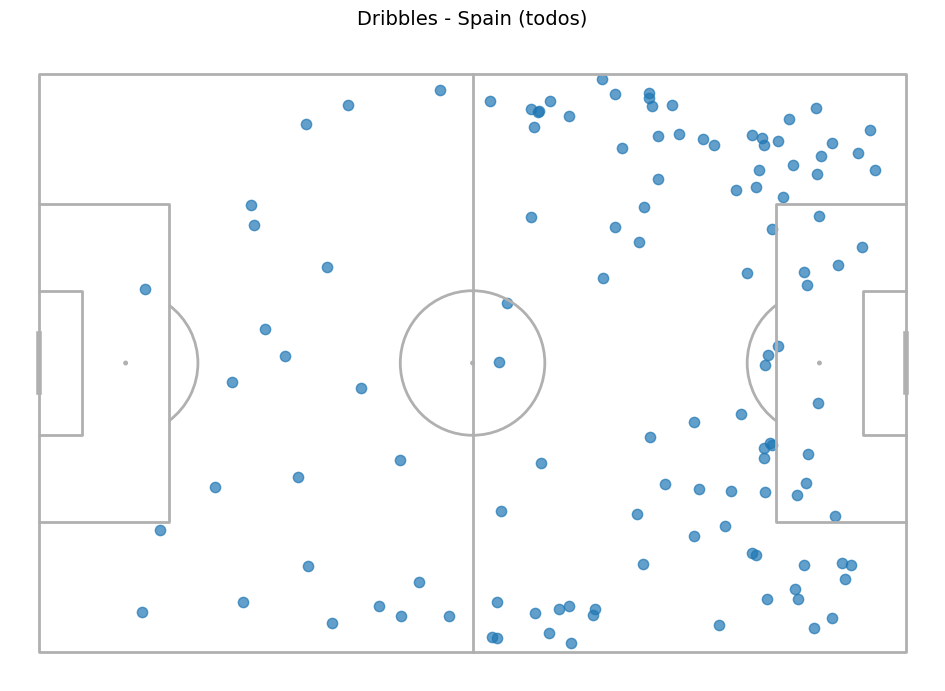

In [17]:
TEAM = dribbles["team"].dropna().value_counts().index[0]
team_d = dribbles[dribbles["team"].eq(TEAM)]

fig, ax = plot_dribbles(team_d, title=f"Dribbles - {TEAM} (todos)")
plt.show()


6) Completados vs fallidos (dos mapas)

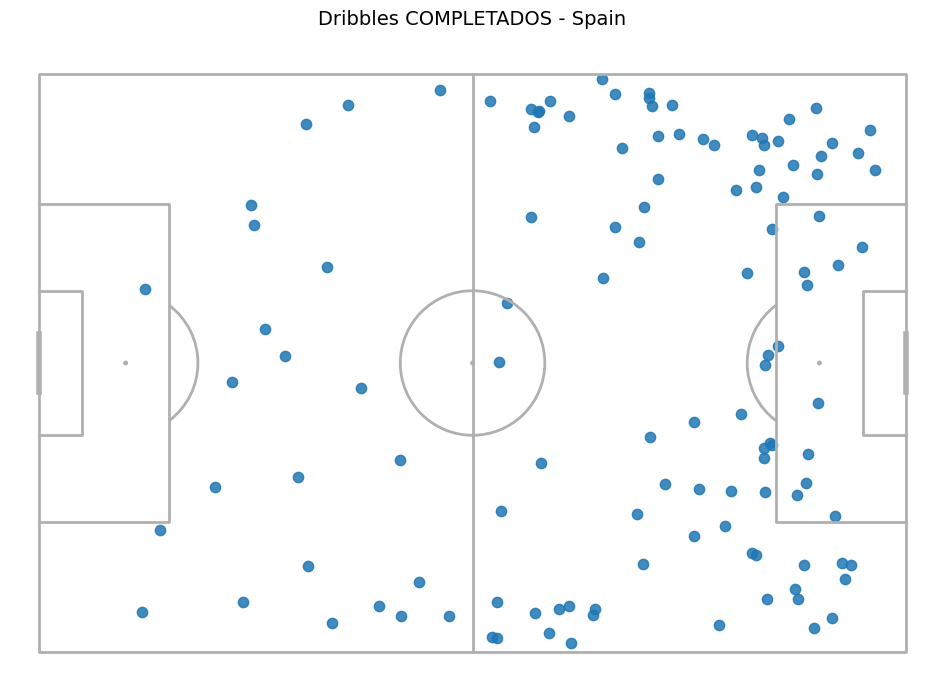

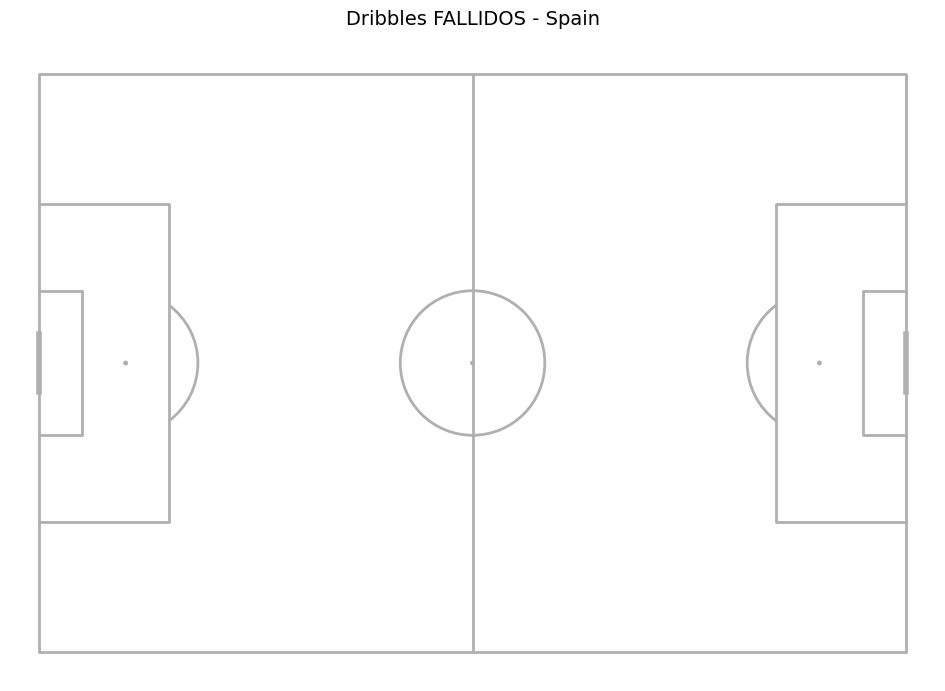

In [18]:
TEAM = dribbles["team"].dropna().value_counts().index[0]
team_d = dribbles[dribbles["team"].eq(TEAM)]

fig, ax = plot_dribbles(team_d[team_d["completed"]], title=f"Dribbles COMPLETADOS - {TEAM}", alpha=0.85)
plt.show()

fig, ax = plot_dribbles(team_d[~team_d["completed"]], title=f"Dribbles FALLIDOS - {TEAM}", alpha=0.85)
plt.show()


7) Top jugadores por intentos / completados

In [8]:
TEAM = dribbles["team"].dropna().value_counts().index[0]
team_d = dribbles[dribbles["team"].eq(TEAM)]

top_attempts = team_d["player"].value_counts().head(10)
top_completed = team_d[team_d["completed"]]["player"].value_counts().head(10)

top_attempts, top_completed


(player
 Nicholas Williams Arthuer      32
 Lamine Yamal Nasraoui Ebana    27
 Daniel Olmo Carvajal           15
 Fabián Ruiz Peña               11
 Daniel Carvajal Ramos           5
 Pedro González López            3
 Álvaro Borja Morata Martín      3
 Marc Cucurella Saseta           3
 Fermin Lopez Marin              3
 Rodrigo Hernández Cascante      3
 Name: count, dtype: int64,
 Series([], Name: count, dtype: int64))

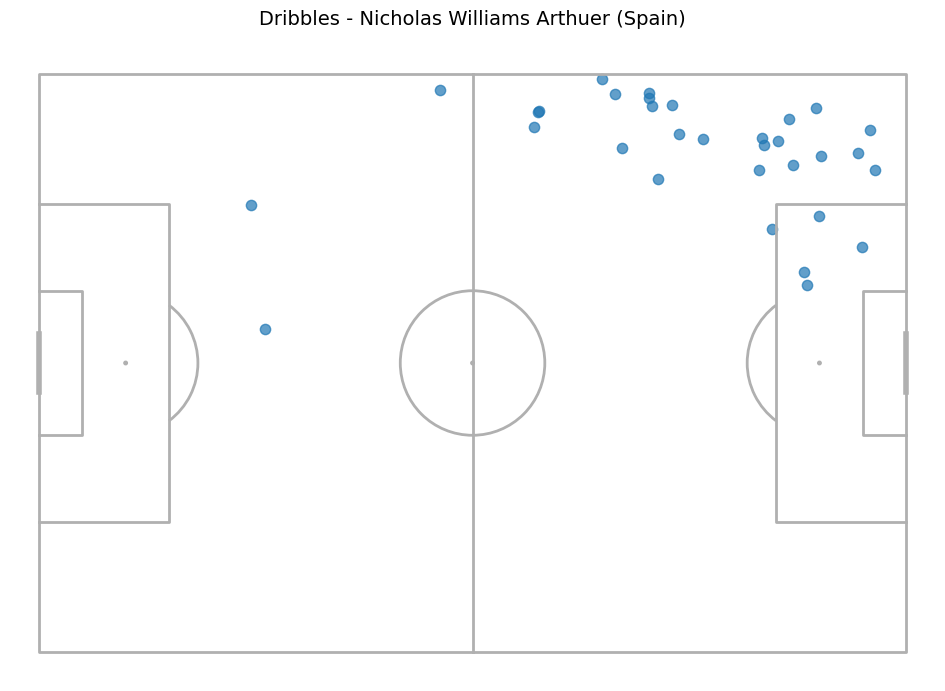

In [9]:
PLAYER = top_attempts.index[0]
p_df = team_d[team_d["player"].eq(PLAYER)]

fig, ax = plot_dribbles(p_df, title=f"Dribbles - {PLAYER} ({TEAM})")
plt.show()


8) Heatmap de zonas de dribble

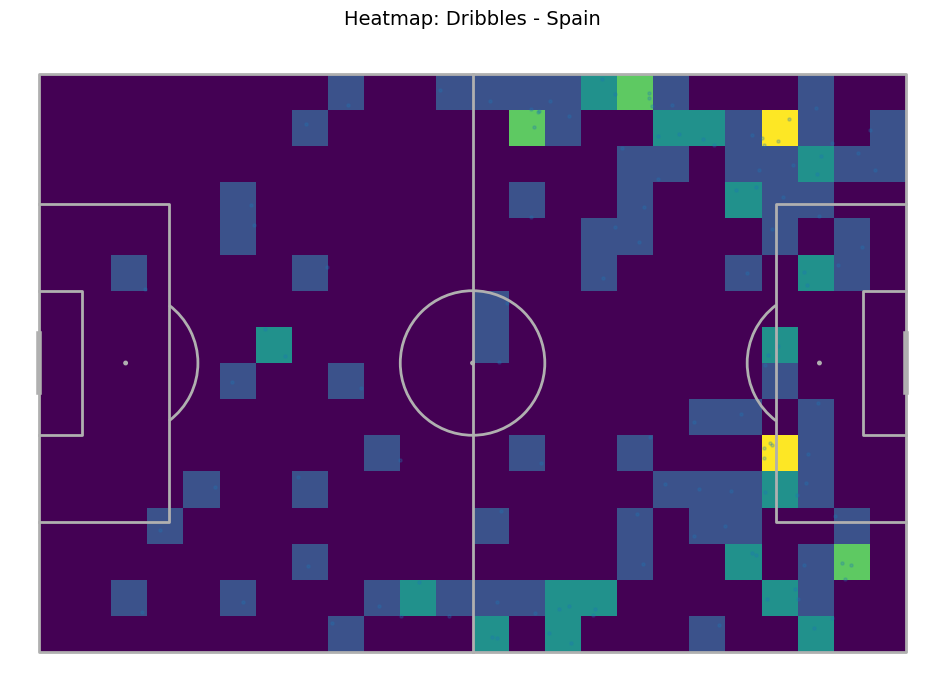

In [10]:
TEAM = dribbles["team"].dropna().value_counts().index[0]
team_d = dribbles[dribbles["team"].eq(TEAM)]

pitch, fig, ax = draw_pitch(title=f"Heatmap: Dribbles - {TEAM}")

bin_stat = pitch.bin_statistic(team_d["x"], team_d["y"], statistic="count", bins=(24, 16))
pitch.heatmap(bin_stat, ax=ax)
pitch.scatter(team_d["x"], team_d["y"], ax=ax, s=5, alpha=0.25)

plt.show()


9) Dribbles por tercios (inicio)

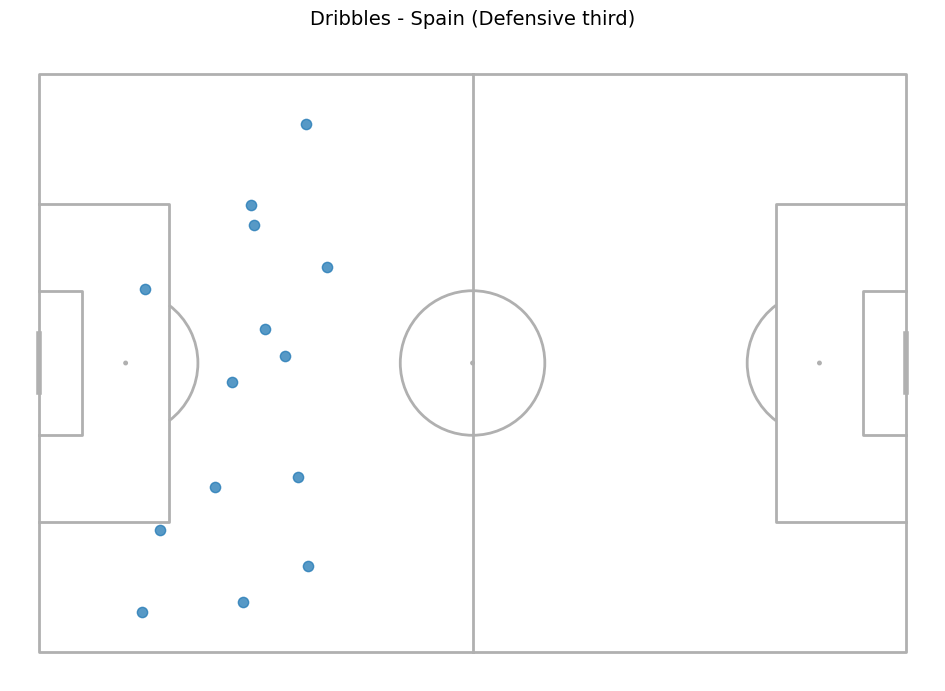

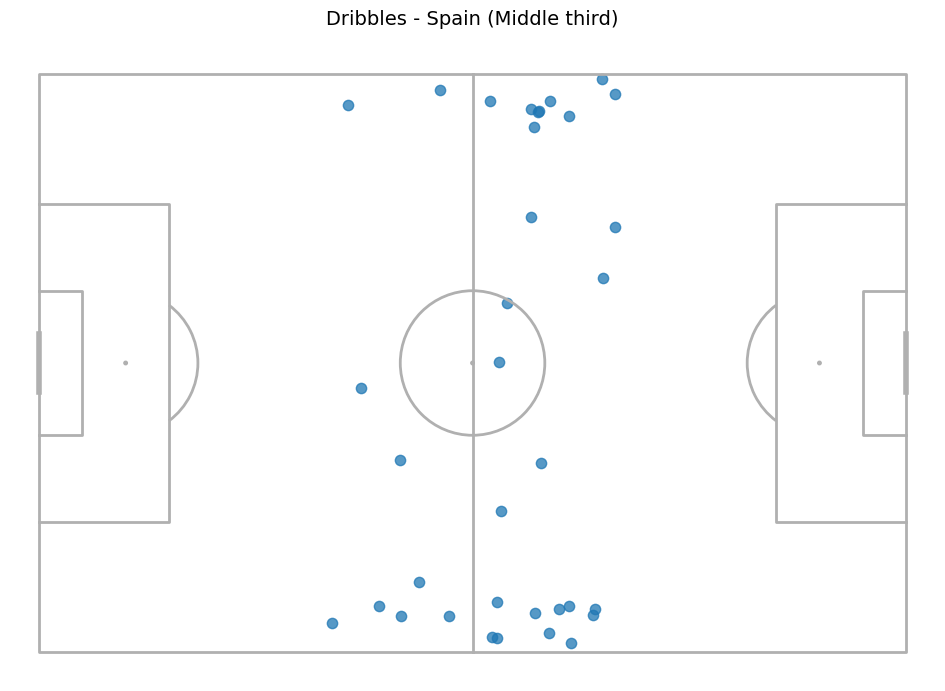

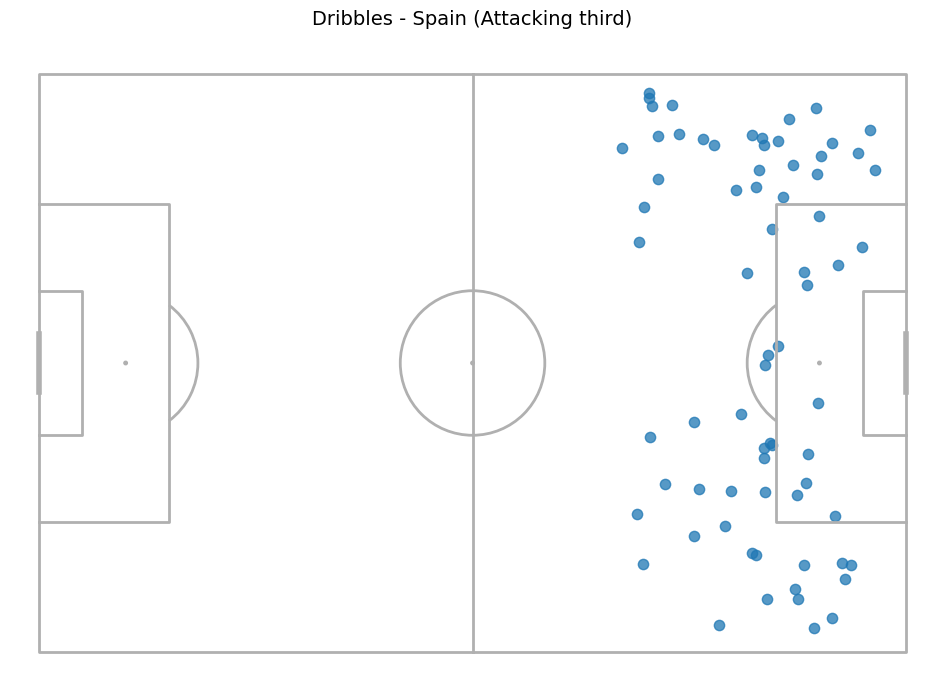

In [11]:
TEAM = dribbles["team"].dropna().value_counts().index[0]
team_d = dribbles[dribbles["team"].eq(TEAM)].copy()

def third(x):
    if x < 40: return "Defensive third"
    if x < 80: return "Middle third"
    return "Attacking third"

team_d["third"] = team_d["x"].apply(third)

for t in ["Defensive third", "Middle third", "Attacking third"]:
    df = team_d[team_d["third"].eq(t)]
    fig, ax = plot_dribbles(df, title=f"Dribbles - {TEAM} ({t})", alpha=0.75)
    plt.show()


10) Dribbles en zonas “peligrosas” (half-space / cerca del área)

Ejemplo simple: dribbles en el último tercio y zona central-amplia.

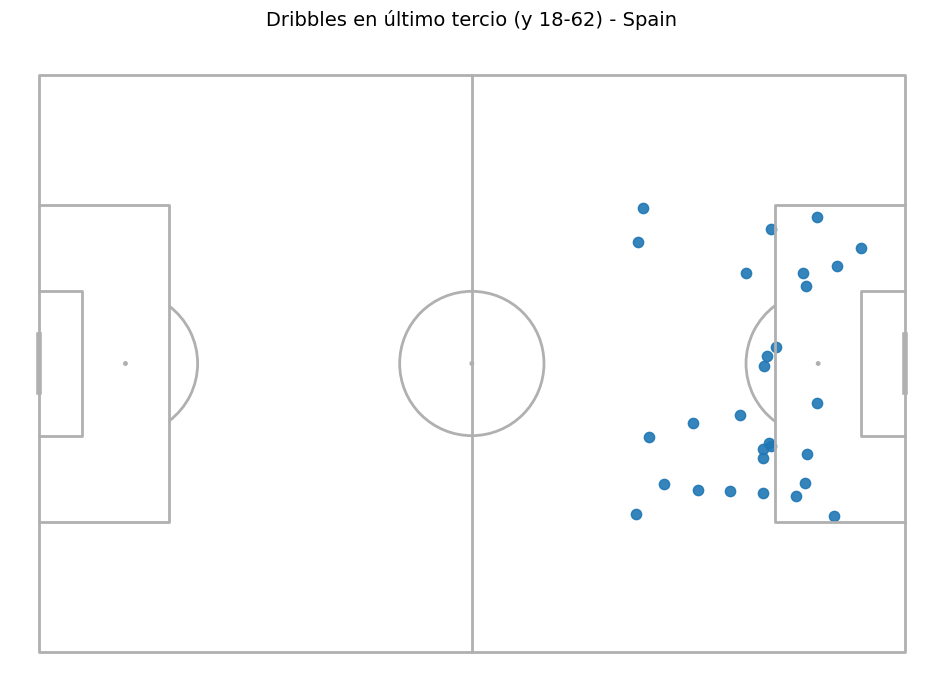

,player,x,y,outcome,minute,second,period
8047,Fabián Ruiz Peña,100.5,40.3,NaN,31,23,1
8161,Pedro González López,84.6,50.2,NaN,36,1,1
9335,Lamine Yamal Nasraoui Ebana,91.4,57.5,NaN,63,47,2
51169,Nicholas Williams Arthuer,113.9,24.0,NaN,2,59,1
52132,Lamine Yamal Nasraoui Ebana,90.6,48.2,NaN,23,22,1
53217,Pedro González López,104.9,58.3,NaN,50,23,2
53226,Lamine Yamal Nasraoui Ebana,100.3,53.1,NaN,50,31,2
54312,Fabián Ruiz Peña,98.0,27.5,NaN,76,0,2
79786,Fermin Lopez Marin,106.4,52.6,NaN,72,17,2
79826,Daniel Olmo Carvajal,83.7,18.4,NaN,72,46,2


In [12]:
TEAM = dribbles["team"].dropna().value_counts().index[0]
team_d = dribbles[dribbles["team"].eq(TEAM)].copy()

danger = team_d[(team_d["x"] >= 80) & (team_d["y"].between(18, 62))]
fig, ax = plot_dribbles(danger, title=f"Dribbles en último tercio (y 18-62) - {TEAM}", alpha=0.9)
plt.show()

danger[["player","x","y","outcome","minute","second","period"]].head(15)


11) Resumen tabular (attempts, completed, success rate)

In [13]:
TEAM = dribbles["team"].dropna().value_counts().index[0]
team_d = dribbles[dribbles["team"].eq(TEAM)].copy()

summary = (
    team_d.groupby("player")
    .agg(
        attempts=("type", "size"),
        completed=("completed", "sum"),
    )
)

summary["success_rate"] = summary["completed"] / summary["attempts"]
summary = summary.sort_values(["completed","attempts"], ascending=False)

summary.head(15)


,attempts,completed,success_rate
player,,,
Nicholas Williams Arthuer,32,0,0.0
Lamine Yamal Nasraoui Ebana,27,0,0.0
Daniel Olmo Carvajal,15,0,0.0
Fabián Ruiz Peña,11,0,0.0
Daniel Carvajal Ramos,5,0,0.0
Fermin Lopez Marin,3,0,0.0
Marc Cucurella Saseta,3,0,0.0
Pedro González López,3,0,0.0
Rodrigo Hernández Cascante,3,0,0.0


Pruebas

In [14]:
# Diagnóstico rápido
print("Columnas dribble relacionadas:")
print([c for c in dribbles.columns if c.startswith("dribble") or c in ["type","team","player"]])

col = "dribble.outcome.name"
if col in dribbles.columns:
    display(dribbles[col].value_counts(dropna=False).head(20))
else:
    print("No existe dribble.outcome.name en este dataset")


Columnas dribble relacionadas:
['type', 'team', 'player']
No existe dribble.outcome.name en este dataset


DRIBBLES — DIAGNÓSTICO
Dataset rows: 187858 | Dribbles: 1280
Columna outcome detectada: dribble_outcome
Value counts outcome (raw, top 10):
outcome_raw
Complete      653
Incomplete    627
Name: count, dtype: int64[pyarrow]
Hay outcomes no-nulos: True
Completed: 653 | Failed: 627


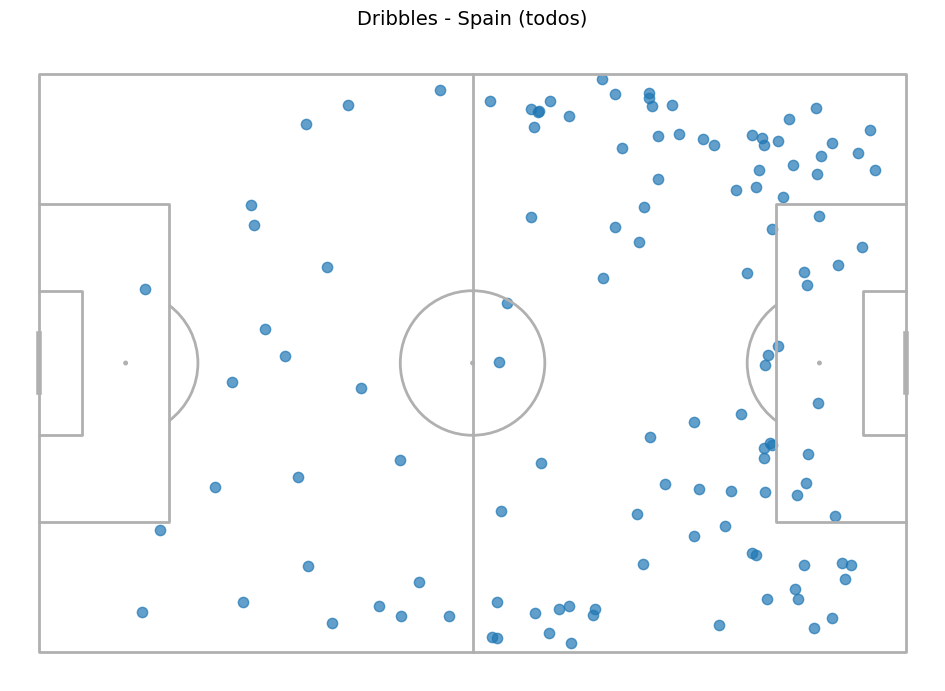

Spain: OK=57 | BAD=63 | TOTAL=120


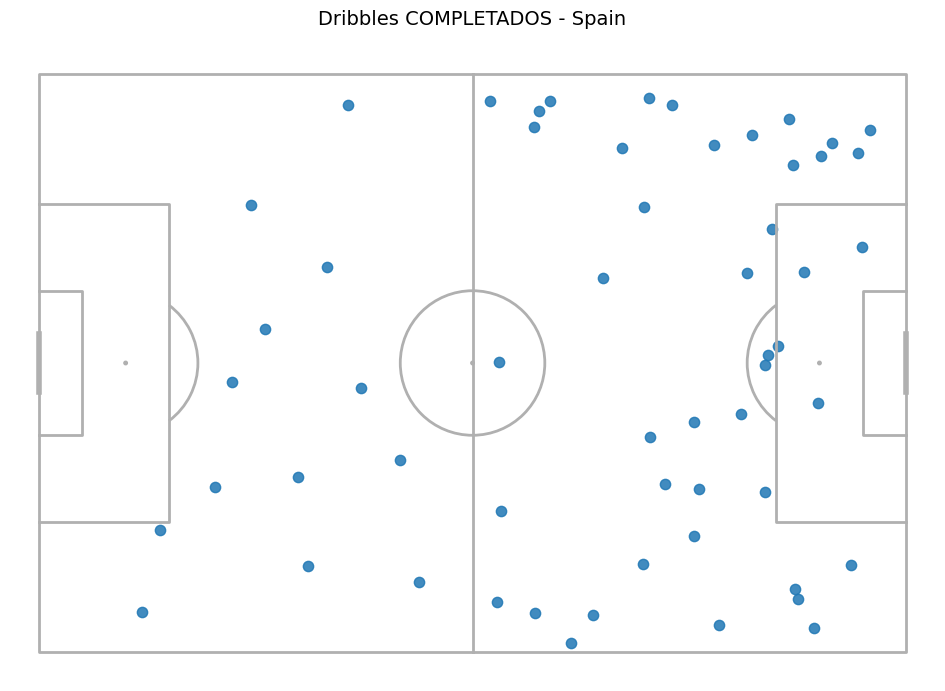

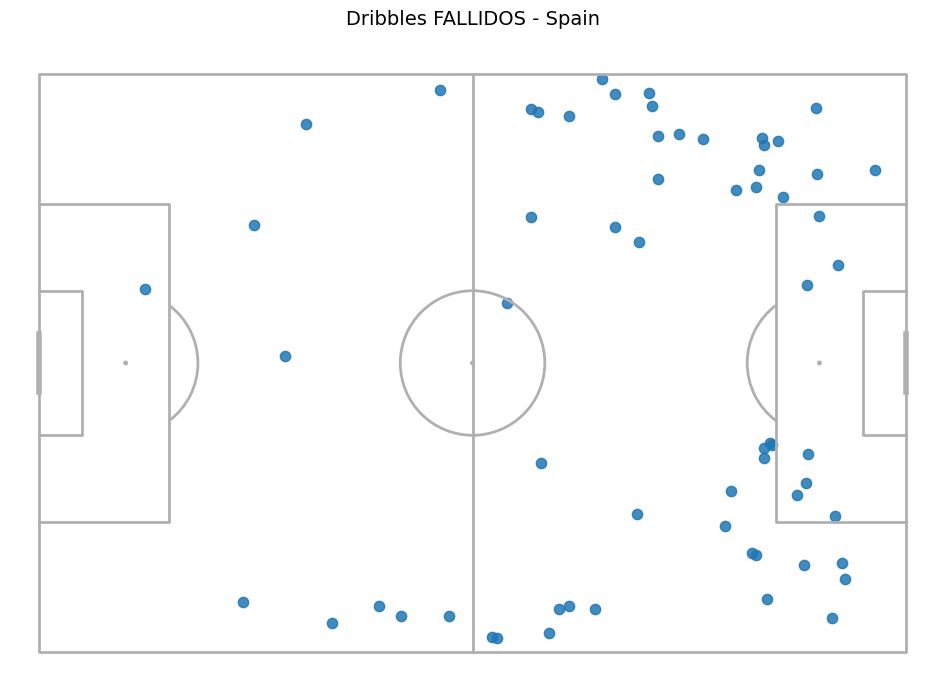


Top 10 por intentos (equipo):
player
Nicholas Williams Arthuer      32
Lamine Yamal Nasraoui Ebana    27
Daniel Olmo Carvajal           15
Fabián Ruiz Peña               11
Daniel Carvajal Ramos           5
Pedro González López            3
Álvaro Borja Morata Martín      3
Marc Cucurella Saseta           3
Fermin Lopez Marin              3
Rodrigo Hernández Cascante      3
Name: count, dtype: int64


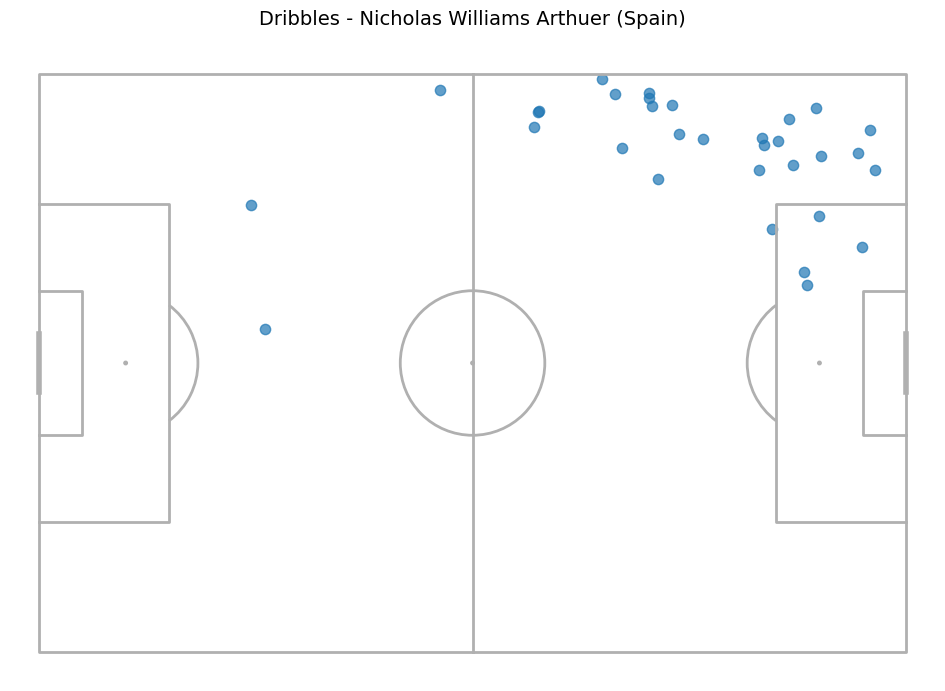

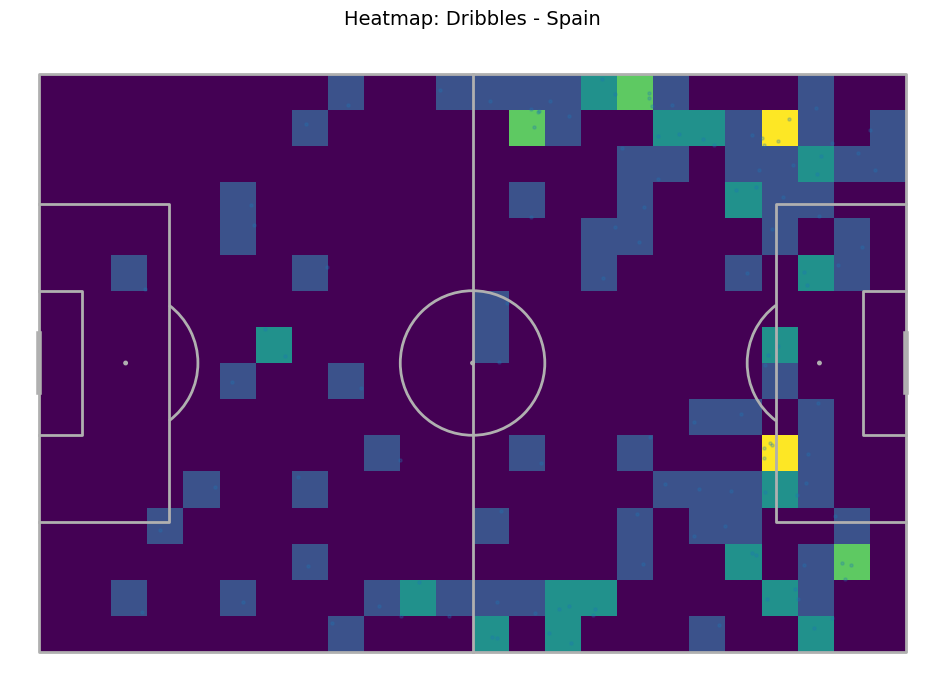

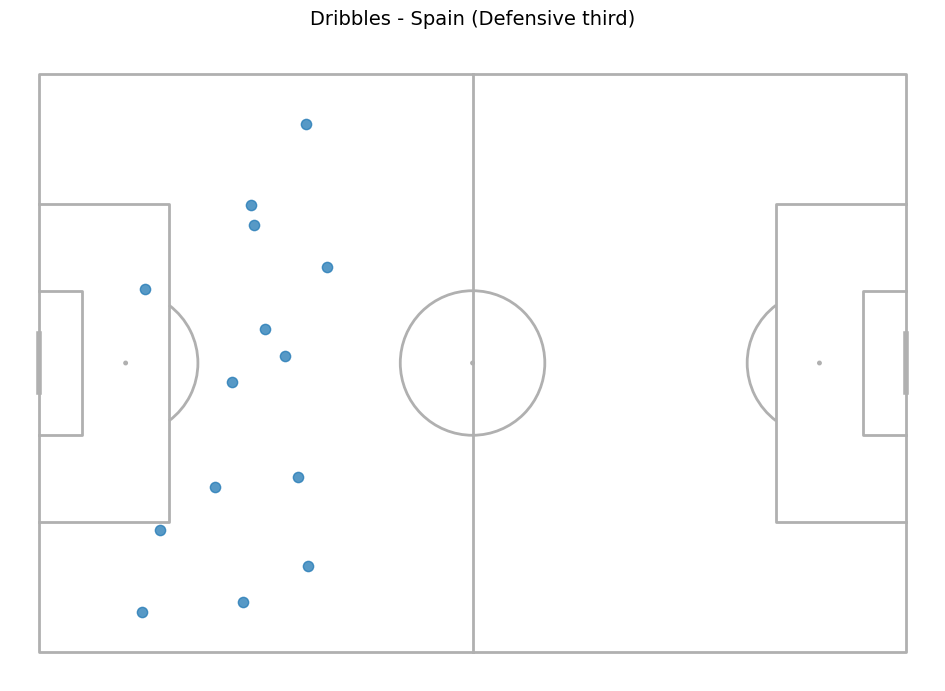

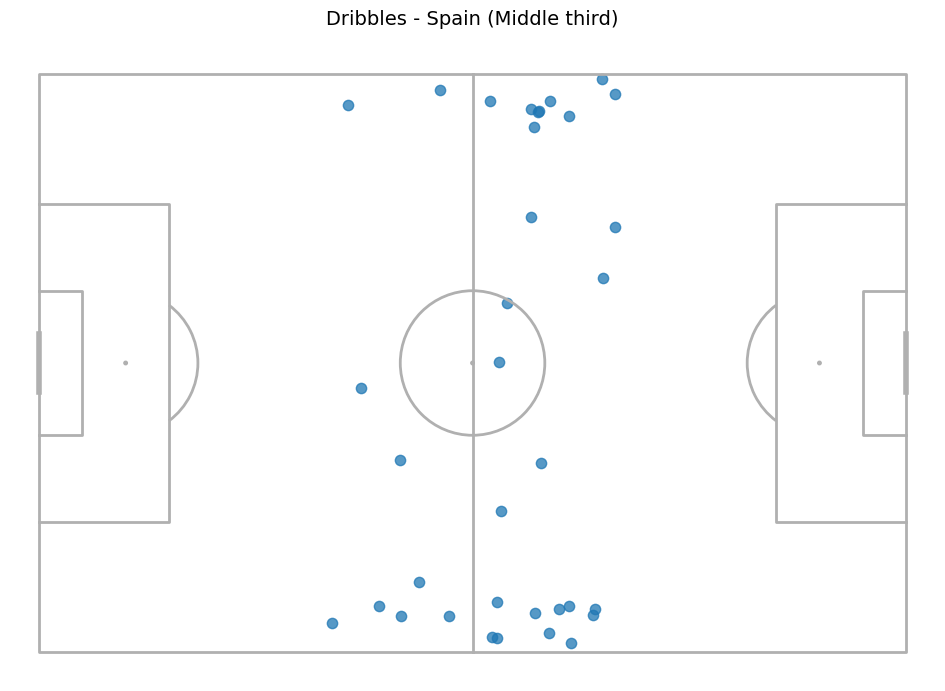

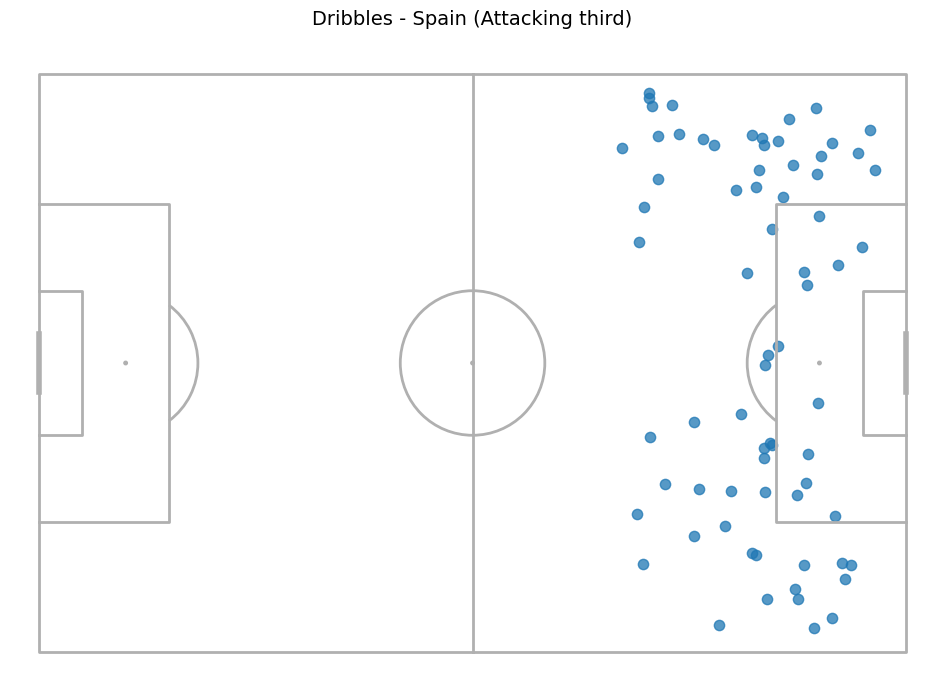

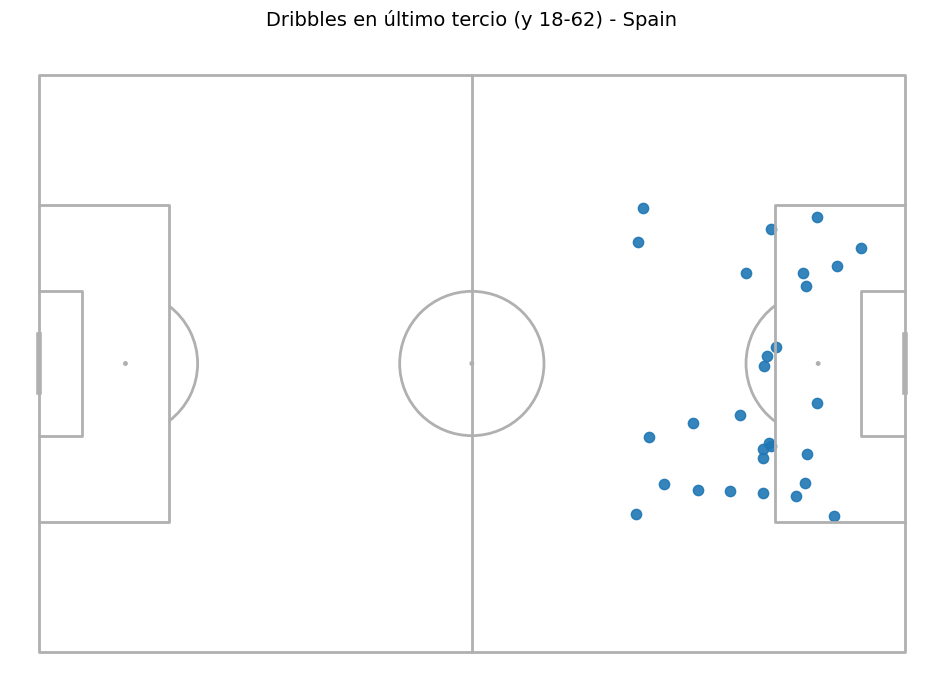


Resumen (top 15):


,attempts,completed,failed,success_rate
player,,,,
Nicholas Williams Arthuer,32,15,17,0.468750
Lamine Yamal Nasraoui Ebana,27,12,15,0.444444
Daniel Olmo Carvajal,15,10,5,0.666667
Fabián Ruiz Peña,11,7,4,0.636364
Ayoze Pérez Gutiérrez,2,2,0,1.000000
Daniel Carvajal Ramos,5,1,4,0.200000
Fermin Lopez Marin,3,1,2,0.333333
Pedro González López,3,1,2,0.333333
Álvaro Borja Morata Martín,3,1,2,0.333333


In [32]:
# ============================================================
# 06_dribble_maps.ipynb — TODO EN UNA SOLA CELDA (CORREGIDO)
# StatsBomb Dribble: robusto ante datasets donde outcome no existe o está vacío
# Requisitos: pandas, numpy, matplotlib, mplsoccer
# ============================================================

import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mplsoccer import Pitch, VerticalPitch

# ---------------------------
# 1) CONFIG: elige UNA ruta
# ---------------------------
DATA_PATH = "../data/processed/events.parquet"          # <- si usas parquet/csv
# EVENTS_JSON = "../data/raw/statsbomb/events/3788741.json"  # <- si usas JSON

# ---------------------------
# 2) CARGA
# ---------------------------
if "EVENTS_JSON" in globals() and os.path.exists(globals().get("EVENTS_JSON","")):
    with open(EVENTS_JSON, "r", encoding="utf-8") as f:
        raw_events = json.load(f)
    events = pd.json_normalize(raw_events, sep=".")
else:
    if not os.path.exists(DATA_PATH):
        raise FileNotFoundError(f"No existe DATA_PATH: {DATA_PATH}")
    events = pd.read_parquet(DATA_PATH) if DATA_PATH.endswith(".parquet") else pd.read_csv(DATA_PATH)

# ---------------------------
# 3) NORMALIZACIÓN MÍNIMA
# ---------------------------
def _unpack_xy(series, idx):
    return series.apply(lambda v: v[idx] if isinstance(v, (list, tuple)) and len(v) > idx else np.nan)

# type
if "type" not in events.columns:
    if "type.name" in events.columns:
        events["type"] = events["type.name"]
    elif "type" in events.columns:
        pass
    else:
        raise ValueError("No encuentro 'type' ni 'type.name'.")

# team / player
if "team" not in events.columns and "team.name" in events.columns:
    events["team"] = events["team.name"]
if "player" not in events.columns and "player.name" in events.columns:
    events["player"] = events["player.name"]

# coords
if "location" in events.columns:
    events["x"] = _unpack_xy(events["location"], 0)
    events["y"] = _unpack_xy(events["location"], 1)
elif not {"x","y"}.issubset(events.columns):
    raise ValueError("No encuentro 'location' ni columnas 'x','y'. Ajusta el mapeo a tu dataset.")

# ---------------------------
# 4) FILTRAR DRIBBLES
# ---------------------------
dribbles = events[events["type"].eq("Dribble")].copy()
if dribbles.empty:
    raise ValueError("No hay eventos con type == 'Dribble' en este dataset.")

# Outcome: probar columnas típicas (por si tu pipeline cambió nombres)
outcome_candidates = [
    "dribble.outcome.name",
    "dribble.outcome",          # a veces es string
    "dribble_outcome",          # pipelines custom
    "dribbleOutcome",           # muy raro
]

out_col = next((c for c in outcome_candidates if c in dribbles.columns), None)

if out_col is None:
    dribbles["outcome_raw"] = pd.Series(pd.NA, index=dribbles.index, dtype="string")
else:
    dribbles["outcome_raw"] = dribbles[out_col].astype("string")

# normaliza strings (maneja espacios, mayúsculas, etc.)
dribbles["outcome"] = (
    dribbles["outcome_raw"]
    .str.strip()
    .str.lower()
)

# ---------------------------
# 5) DEFINICIÓN ROBUSTA DE COMPLETED/FAILED
# ---------------------------
# En muchos datasets StatsBomb: outcome aparece solo cuando NO se completa.
# Si outcome está vacío/NA en la mayoría -> no podemos inferir "failed" salvo que existan valores.
# Lógica:
# - Si hay outcomes no nulos:
#     completed = outcome en términos de éxito  OR (outcome es NA y se asume éxito solo si el dataset sigue convención SB)
#     failed    = outcome en términos de fallo
# - Si NO hay outcomes no nulos:
#     completed/failed quedan en NA y se trabaja con "dribbles totales"

completed_terms = {"complete", "completed", "successful", "success", "won"}
failed_terms    = {"incomplete", "incompleted", "unsuccessful", "failed", "fail", "lost"}

has_any_outcome = dribbles["outcome"].notna().any()

if has_any_outcome:
    # Si hay outcomes, interpretamos:
    #  - failed si outcome indica fallo
    #  - completed si outcome indica éxito
    #  - si outcome es NA, en StatsBomb suele significar completado (cuando solo registran fallo)
    dribbles["failed"] = dribbles["outcome"].isin(failed_terms)
    dribbles["completed"] = dribbles["outcome"].isin(completed_terms) | dribbles["outcome"].isna()
else:
    dribbles["failed"] = pd.Series(pd.NA, index=dribbles.index)
    dribbles["completed"] = pd.Series(pd.NA, index=dribbles.index)

# ---------------------------
# 6) HELPERS DE PLOT
# ---------------------------
def draw_pitch(title=None, vertical=False):
    pitch = VerticalPitch(pitch_type="statsbomb", line_zorder=2) if vertical else Pitch(pitch_type="statsbomb", line_zorder=2)
    fig, ax = pitch.draw(figsize=(10, 7))
    if title:
        fig.suptitle(title, fontsize=14)
    return pitch, fig, ax

def plot_dribbles(df, title, vertical=False, s=55, alpha=0.7):
    pitch, fig, ax = draw_pitch(title=title, vertical=vertical)
    pitch.scatter(df["x"], df["y"], ax=ax, s=s, alpha=alpha)
    return fig, ax

# ---------------------------
# 7) SELECCIÓN DE EQUIPO Y JUGADOR TOP
# ---------------------------
if dribbles["team"].notna().any():
    TEAM = dribbles["team"].dropna().value_counts().index[0]
    team_d = dribbles[dribbles["team"].eq(TEAM)].copy()
else:
    TEAM = "ALL"
    team_d = dribbles.copy()

# ---------------------------
# 8) DIAGNÓSTICO IMPRESO
# ---------------------------
print("===============================================")
print("DRIBBLES — DIAGNÓSTICO")
print("Dataset rows:", len(events), "| Dribbles:", len(dribbles))
print("Columna outcome detectada:", out_col)
if out_col is not None:
    print("Value counts outcome (raw, top 10):")
    print(dribbles["outcome_raw"].value_counts(dropna=False).head(10))
else:
    print("No hay columna outcome en tu dataset.")
print("Hay outcomes no-nulos:", has_any_outcome)
if has_any_outcome:
    print("Completed:", int(dribbles["completed"].sum()), "| Failed:", int(dribbles["failed"].sum()))
print("===============================================")

# ---------------------------
# 9) PLOT 5) — TODOS LOS DRIBBLES DEL EQUIPO
# ---------------------------
fig, ax = plot_dribbles(team_d, title=f"Dribbles - {TEAM} (todos)")
plt.show()

# ---------------------------
# 10) PLOT 6) — COMPLETADOS VS FALLIDOS (SI SE PUEDE)
# ---------------------------
if team_d["completed"].notna().any():
    ok = team_d[team_d["completed"] == True]
    bad = team_d[team_d["failed"] == True]

    print(f"{TEAM}: OK={len(ok)} | BAD={len(bad)} | TOTAL={len(team_d)}")

    if not ok.empty:
        fig, ax = plot_dribbles(ok, title=f"Dribbles COMPLETADOS - {TEAM}", alpha=0.85)
        plt.show()
    else:
        print("⚠️ No hay dribbles marcados como completados (según tu outcome).")

    if not bad.empty:
        fig, ax = plot_dribbles(bad, title=f"Dribbles FALLIDOS - {TEAM}", alpha=0.85)
        plt.show()
    else:
        print("⚠️ No hay dribbles marcados como fallidos (según tu outcome).")
else:
    print("⚠️ Este dataset no permite separar completados/fallidos (outcome inexistente o vacío).")

# ---------------------------
# 11) TOP JUGADORES + MAPA DEL TOP
# ---------------------------
if team_d["player"].notna().any():
    top_attempts = team_d["player"].value_counts().head(10)
    print("\nTop 10 por intentos (equipo):")
    print(top_attempts)

    PLAYER = top_attempts.index[0]
    p_df = team_d[team_d["player"].eq(PLAYER)]
    fig, ax = plot_dribbles(p_df, title=f"Dribbles - {PLAYER} ({TEAM})")
    plt.show()
else:
    print("No hay columna player con datos; salto top jugadores.")

# ---------------------------
# 12) HEATMAP (ZONAS)
# ---------------------------
pitch, fig, ax = draw_pitch(title=f"Heatmap: Dribbles - {TEAM}")
bin_stat = pitch.bin_statistic(team_d["x"], team_d["y"], statistic="count", bins=(24, 16))
pitch.heatmap(bin_stat, ax=ax)
pitch.scatter(team_d["x"], team_d["y"], ax=ax, s=5, alpha=0.25)
plt.show()

# ---------------------------
# 13) DRIBBLES POR TERCIOS
# ---------------------------
def third(x):
    if x < 40: return "Defensive third"
    if x < 80: return "Middle third"
    return "Attacking third"

team_d["third"] = team_d["x"].apply(third)

for t in ["Defensive third", "Middle third", "Attacking third"]:
    df = team_d[team_d["third"].eq(t)]
    fig, ax = plot_dribbles(df, title=f"Dribbles - {TEAM} ({t})", alpha=0.75)
    plt.show()

# ---------------------------
# 14) ZONA "PELIGRO" (último tercio y y central)
# ---------------------------
danger = team_d[(team_d["x"] >= 80) & (team_d["y"].between(18, 62))]
fig, ax = plot_dribbles(danger, title=f"Dribbles en último tercio (y 18-62) - {TEAM}", alpha=0.9)
plt.show()

# ---------------------------
# 15) TABLA RESUMEN (PUNTO 11 CORREGIDO)
# ---------------------------
summary = team_d.groupby("player").agg(attempts=("type","size")) if team_d["player"].notna().any() else None

if summary is not None:
    if team_d["completed"].notna().any():
        comp = team_d.groupby("player")["completed"].sum()
        fail = team_d.groupby("player")["failed"].sum()
        summary["completed"] = comp
        summary["failed"] = fail
        summary["success_rate"] = summary["completed"] / summary["attempts"]
        summary = summary.sort_values(["completed","attempts"], ascending=False)
    else:
        summary = summary.sort_values("attempts", ascending=False)

    print("\nResumen (top 15):")
    display(summary.head(15))
else:
    print("No se puede generar tabla por jugador (no hay columna player con datos).")


In [31]:
import pandas as pd

df = pd.read_parquet("../data/processed/events.parquet")

# Columnas sospechosas
cols = [c for c in df.columns if "dribble" in c.lower() or "outcome" in c.lower()]
print(cols)


['pass_outcome', 'dribble_outcome', 'dribble_nutmeg', 'dribble_overrun', 'dribble_no_touch', 'shot_outcome']


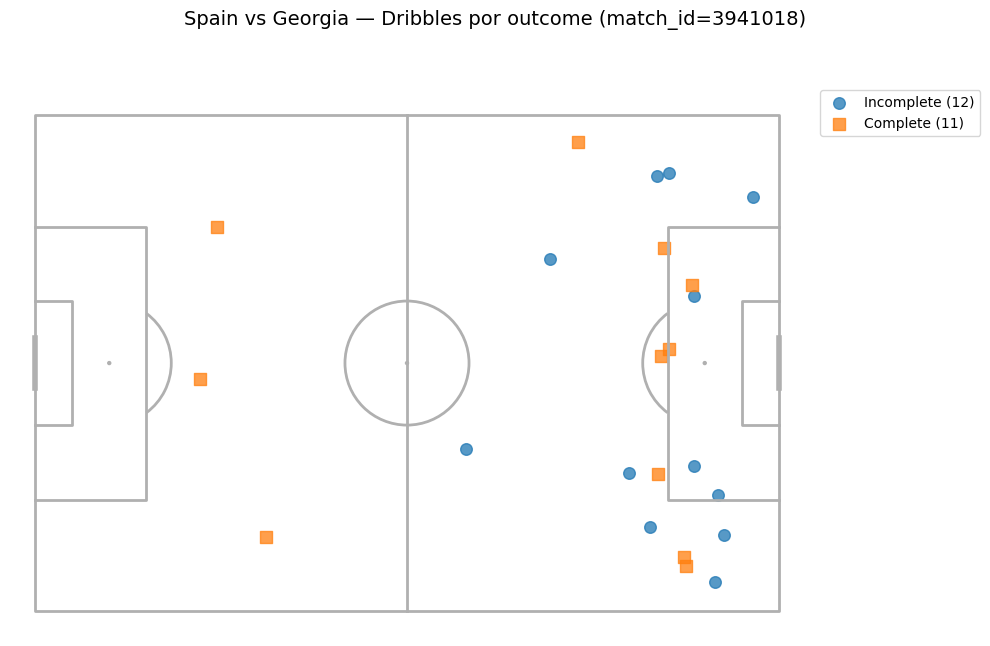

outcome
Incomplete    12
Complete      11
Name: count, dtype: int64[pyarrow]

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
from mplsoccer import Pitch

events = pd.read_parquet("../data/processed/events.parquet")

# --- Dribbles de España ---
spain_dr = events[(events["team"] == "Spain") & (events["type"] == "Dribble")].copy()
if spain_dr.empty:
    spain_dr = events[(events["team"].astype(str).str.contains("Spain", case=False, na=False)) & (events["type"] == "Dribble")].copy()
if spain_dr.empty:
    raise ValueError("No encuentro dribbles de Spain en el dataset. Revisa cómo se llama el equipo en 'team'.")

# --- Match: el que tenga más dribbles ---
MATCH_ID = int(spain_dr["match_id"].value_counts().index[0])
match_events = events[events["match_id"] == MATCH_ID].copy()

# --- Rival: equipo no-Spain más frecuente en los eventos del partido ---
teams_in_match = match_events["team"].dropna()
rival = teams_in_match[teams_in_match != "Spain"].value_counts().index[0] if (teams_in_match != "Spain").any() else "Unknown opponent"

match_dr = spain_dr[spain_dr["match_id"] == MATCH_ID].copy()

# outcome (si no existe o NaN)
match_dr["outcome"] = match_dr.get("dribble_outcome", pd.Series(pd.NA, index=match_dr.index)).astype("string")
match_dr["outcome"] = match_dr["outcome"].fillna("Unknown").str.strip()

# --- Plot ---
pitch = Pitch(pitch_type="statsbomb", line_zorder=2)
fig, ax = pitch.draw(figsize=(10, 7))
fig.suptitle(f"Spain vs {rival} — Dribbles por outcome (match_id={MATCH_ID})", fontsize=14)

markers = ["o","s","^","D","P","X","v","<",">","*","h","+","1","2","3","4"]
outcomes = list(match_dr["outcome"].value_counts().index)

for i, oc in enumerate(outcomes):
    df = match_dr[match_dr["outcome"] == oc]
    pitch.scatter(
        df["x"], df["y"],
        ax=ax, s=70, alpha=0.75,
        marker=markers[i % len(markers)],
        label=f"{oc} ({len(df)})"
    )

ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0)
plt.tight_layout()
plt.show()

display(match_dr["outcome"].value_counts())


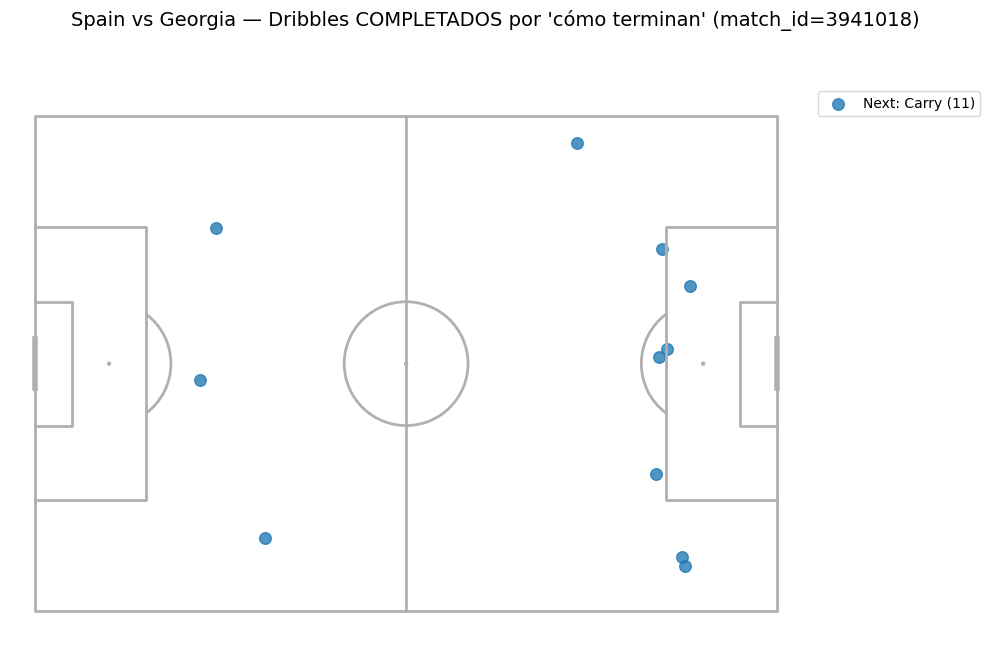

terminal
Next: Carry    11
Name: count, dtype: int64

,minute,second,x,y,terminal,next_event_type,next_event_index
92,1,20,87.6,4.3,Next: Carry,Carry,94
822,19,33,102.2,37.7,Next: Carry,Carry,824
1665,37,35,29.3,18.1,Next: Carry,Carry,1667
2346,54,17,37.2,68.1,Next: Carry,Carry,2348
2467,57,33,105.0,72.7,Next: Carry,Carry,2469
2470,57,34,104.6,71.3,Next: Carry,Carry,2472
3243,74,28,26.7,42.6,Next: Carry,Carry,3245
3250,74,38,101.4,21.4,Next: Carry,Carry,3252
3299,76,57,105.9,27.4,Next: Carry,Carry,3301
3514,82,34,100.9,38.9,Next: Carry,Carry,3516


In [35]:
import pandas as pd
import matplotlib.pyplot as plt
from mplsoccer import Pitch

events = pd.read_parquet("../data/processed/events.parquet")

# --- Dribbles de España ---
spain_dr = events[(events["team"] == "Spain") & (events["type"] == "Dribble")].copy()
if spain_dr.empty:
    spain_dr = events[(events["team"].astype(str).str.contains("Spain", case=False, na=False)) & (events["type"] == "Dribble")].copy()
if spain_dr.empty:
    raise ValueError("No encuentro dribbles de Spain en el dataset. Revisa cómo se llama el equipo en 'team'.")

# --- Match: el que tenga más dribbles ---
MATCH_ID = int(spain_dr["match_id"].value_counts().index[0])
match_events = events[events["match_id"] == MATCH_ID].copy()

# --- Rival ---
teams_in_match = match_events["team"].dropna()
rival = teams_in_match[teams_in_match != "Spain"].value_counts().index[0] if (teams_in_match != "Spain").any() else "Unknown opponent"

# --- Asegura orden por index (StatsBomb) ---
match_events = match_events.sort_values("index").reset_index(drop=True)

# --- Dribbles completados ---
if "dribble_outcome" not in match_events.columns:
    raise ValueError("No existe 'dribble_outcome' en processed. Re-genera processed con el script corregido.")

completed = match_events[
    (match_events["team"] == "Spain") &
    (match_events["type"] == "Dribble") &
    (match_events["dribble_outcome"] == "Complete")
].copy()

if completed.empty:
    raise ValueError("No hay dribbles completados (dribble_outcome == 'Complete') para Spain en este partido.")

# --- Mapa index -> posición en dataframe para localizar el siguiente evento rápido ---
# (index de StatsBomb es único en un partido)
pos_by_index = {idx: i for i, idx in enumerate(match_events["index"].tolist())}

def terminal_label(next_ev: pd.Series) -> str:
    t = str(next_ev.get("type"))
    if t == "Pass":
        oc = next_ev.get("pass_outcome")
        oc = "Complete" if pd.isna(oc) or oc in [None, "None", "nan"] else str(oc)
        return f"Next: Pass ({oc})"
    if t == "Shot":
        oc = next_ev.get("shot_outcome")
        oc = "Unknown" if pd.isna(oc) else str(oc)
        return f"Next: Shot ({oc})"
    if t == "Carry":
        return "Next: Carry"
    if t in ["Foul Won","Foul Committed","Dispossessed","Miscontrol","Ball Receipt*","Ball Recovery","Pressure","Duel","Interception","Clearance"]:
        return f"Next: {t}"
    return f"Next: {t}"

# --- Para cada dribble, buscar el siguiente evento de Spain ---
terminal = []
next_type = []
next_index = []

for _, dr in completed.iterrows():
    cur_pos = pos_by_index.get(dr["index"], None)
    if cur_pos is None:
        terminal.append("Next: Unknown")
        next_type.append(None)
        next_index.append(None)
        continue

    # buscar hacia delante el siguiente evento del mismo equipo
    label = "Next: (none found)"
    ni = None
    nt = None
    for j in range(cur_pos + 1, len(match_events)):
        ev = match_events.iloc[j]
        if ev.get("team") == "Spain":
            label = terminal_label(ev)
            ni = ev.get("index")
            nt = ev.get("type")
            break

    terminal.append(label)
    next_index.append(ni)
    next_type.append(nt)

completed["terminal"] = terminal
completed["next_event_index"] = next_index
completed["next_event_type"] = next_type

# --- Plot: todos los terminal outcomes/categorías (sin límite de 6) ---
pitch = Pitch(pitch_type="statsbomb", line_zorder=2)
fig, ax = pitch.draw(figsize=(10, 7))
fig.suptitle(f"Spain vs {rival} — Dribbles COMPLETADOS por 'cómo terminan' (match_id={MATCH_ID})", fontsize=14)

cats = completed["terminal"].value_counts().index.tolist()

# markers suficientes para muchas categorías; si hay más, se ciclan (la leyenda sigue mostrando todas)
markers = ["o","s","^","D","P","X","v","<",">","*","h","+","1","2","3","4","p","H","d","|","_"]
for i, cat in enumerate(cats):
    df = completed[completed["terminal"] == cat]
    pitch.scatter(
        df["x"], df["y"],
        ax=ax, s=70, alpha=0.78,
        marker=markers[i % len(markers)],
        label=f"{cat} ({len(df)})"
    )

ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0)
plt.tight_layout()
plt.show()

# --- Tabla resumen ---
display(completed["terminal"].value_counts())
display(completed[["minute","second","x","y","terminal","next_event_type","next_event_index"]].head(25))
